# K-Protoypes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import joblib

## Cargar datos

In [3]:
df = pd.read_csv("../data/processed/olist_engineering.csv")
df_scaled = pd.read_csv("../data/processed/olist_scaled.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category_name  115878 non-null  str    
 1   payment_value          115878 non-null  float64
 2   day_moment             115878 non-null  str    
 3   day_type               115878 non-null  str    
 4   season                 115878 non-null  str    
 5   hour                   115878 non-null  int64  
 6   hour_spline_0          115878 non-null  float64
 7   hour_spline_1          115878 non-null  float64
 8   hour_spline_2          115878 non-null  float64
 9   hour_spline_3          115878 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 8.8 MB


In [4]:
df.head()

,product_category_name,payment_value,day_moment,day_type,season,hour,hour_spline_0,hour_spline_1,hour_spline_2,hour_spline_3
0,housewares,18.12,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490
1,housewares,2.00,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490
2,housewares,18.59,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490
3,perfumery,141.46,night,weekday,Summer,20,0.492630,0.465467,0.018232,0.023671
4,auto,179.12,morning,weekday,Summer,8,0.009986,0.037588,0.543506,0.408920


In [5]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category_name  115878 non-null  str    
 1   payment_value          115878 non-null  float64
 2   day_moment             115878 non-null  str    
 3   day_type               115878 non-null  str    
 4   season                 115878 non-null  str    
 5   hour                   115878 non-null  int64  
 6   hour_spline_0          115878 non-null  float64
 7   hour_spline_1          115878 non-null  float64
 8   hour_spline_2          115878 non-null  float64
 9   hour_spline_3          115878 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 8.8 MB


In [6]:
columns = ["payment_value", "hour_spline_0", "hour_spline_1", "hour_spline_2", "hour_spline_3"]
df_scaled[columns] = df_scaled[columns].astype("float32")
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category_name  115878 non-null  str    
 1   payment_value          115878 non-null  float32
 2   day_moment             115878 non-null  str    
 3   day_type               115878 non-null  str    
 4   season                 115878 non-null  str    
 5   hour                   115878 non-null  int64  
 6   hour_spline_0          115878 non-null  float32
 7   hour_spline_1          115878 non-null  float32
 8   hour_spline_2          115878 non-null  float32
 9   hour_spline_3          115878 non-null  float32
dtypes: float32(5), int64(1), str(4)
memory usage: 6.6 MB


### KPrototypes Clustering

In [7]:
columns = ["product_category_name", "payment_value", "day_moment", "day_type", "season", 
            "hour_spline_0", "hour_spline_1", "hour_spline_2", "hour_spline_3"]

model = KPrototypes(n_clusters=4, init="cao", n_init=1, verbose=1, max_iter=100, random_state=42)

clusters = model.fit_predict(df_scaled[columns], categorical=[0, 2, 3, 4])

Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 58059, ncost: 119796.81199654569
Run: 1, iteration: 2/100, moves: 14199, ncost: 109227.91925572991
Run: 1, iteration: 3/100, moves: 3907, ncost: 105846.20946362606
Run: 1, iteration: 4/100, moves: 1066, ncost: 105197.07345960345
Run: 1, iteration: 5/100, moves: 580, ncost: 104953.35647169923
Run: 1, iteration: 6/100, moves: 302, ncost: 104879.58065865017
Run: 1, iteration: 7/100, moves: 154, ncost: 104856.25172515078
Run: 1, iteration: 8/100, moves: 88, ncost: 104847.59994782326
Run: 1, iteration: 9/100, moves: 36, ncost: 104844.75228663703
Run: 1, iteration: 10/100, moves: 3, ncost: 104844.74152420968
Run: 1, iteration: 11/100, moves: 0, ncost: 104844.74152420968


In [8]:
pd.Series(clusters).value_counts()

1    43423
0    41500
3    27420
2     3535
Name: count, dtype: int64

In [9]:
df["cluster"] = clusters
df

,product_category_name,payment_value,day_moment,day_type,season,hour,hour_spline_0,hour_spline_1,hour_spline_2,hour_spline_3,cluster
0,housewares,18.12,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
1,housewares,2.00,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
2,housewares,18.59,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
3,perfumery,141.46,night,weekday,Summer,20,0.492630,0.465467,0.018232,0.023671,1
4,auto,179.12,morning,weekday,Summer,8,0.009986,0.037588,0.543506,0.408920,3
...,...,...,...,...,...,...,...,...,...,...,...
115873,baby,195.00,afternoon,weekday,Winter,12,0.213597,0.000110,0.126860,0.659434,0
115874,home_appliances_2,271.01,afternoon,weekend,Summer,14,0.437481,0.013698,0.030095,0.518726,0
115875,computers_accessories,441.16,night,weekday,Winter,21,0.380031,0.566724,0.046232,0.007014,1
115876,computers_accessories,441.16,night,weekday,Winter,21,0.380031,0.566724,0.046232,0.007014,1


In [10]:
df_scaled["cluster"] = clusters
df_scaled

,product_category_name,payment_value,day_moment,day_type,season,hour,hour_spline_0,hour_spline_1,hour_spline_2,hour_spline_3,cluster
0,housewares,-0.577736,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
1,housewares,-0.637860,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
2,housewares,-0.575983,morning,weekday,Autumn,10,0.067300,0.002959,0.322251,0.607490,3
3,perfumery,-0.117700,night,weekday,Summer,20,0.492630,0.465467,0.018232,0.023671,1
4,auto,0.022764,morning,weekday,Summer,8,0.009986,0.037588,0.543506,0.408920,3
...,...,...,...,...,...,...,...,...,...,...,...
115873,baby,0.081994,afternoon,weekday,Winter,12,0.213597,0.000110,0.126860,0.659434,0
115874,home_appliances_2,0.365497,afternoon,weekend,Summer,14,0.437481,0.013698,0.030095,0.518726,0
115875,computers_accessories,1.000125,night,weekday,Winter,21,0.380031,0.566724,0.046232,0.007014,1
115876,computers_accessories,1.000125,night,weekday,Winter,21,0.380031,0.566724,0.046232,0.007014,1


In [11]:
df_customer_profile = df.groupby("cluster").agg(
    top_products=("product_category_name", lambda x: x.value_counts().head(3).index.to_list()),
    payment_avg=("payment_value", "mean"),
    payment_median=("payment_value", "median"),
    day_moment_mode=("day_moment", lambda x: x.mode().iloc[0]),
    day_type_mode=("day_type", lambda x: x.mode().iloc[0]),
    season_mode=("season", lambda x: x.mode().iloc[0]),
    hour_avg=("hour", "mean"),
    hour_mode=("hour", lambda x: x.mode().iloc[0])
    
)

df_customer_profile["customers_count"] = df["cluster"].value_counts()
df_customer_profile

,top_products,payment_avg,payment_median,day_moment_mode,day_type_mode,season_mode,hour_avg,hour_mode,customers_count
cluster,,,,,,,,,
0,"[bed_bath_table, health_beauty, sports_leisure]",142.403087,106.160,afternoon,weekday,Summer,14.627108,16,41500
1,"[bed_bath_table, health_beauty, furniture_decor]",136.747861,103.350,night,weekday,Summer,18.141423,21,43423
2,"[computers_accessories, watches_gifts, health_...",1228.834438,987.150,afternoon,weekday,Spring,14.577652,14,3535
3,"[bed_bath_table, health_beauty, sports_leisure]",140.669683,106.145,morning,weekday,Spring,9.646280,11,27420


In [12]:
day_ordered = ["night", "afternoon", "morning"]
df_customer_profile["day_moment_mode"] = pd.Categorical(df_customer_profile["day_moment_mode"], 
                                                        categories=day_ordered , ordered=True)

In [13]:
season_ordered = ['Spring', 'Summer', 'Autumn', 'Winter']
df_customer_profile["season_mode"] = pd.Categorical(df_customer_profile["season_mode"], 
                                                        categories=season_ordered , ordered=True)

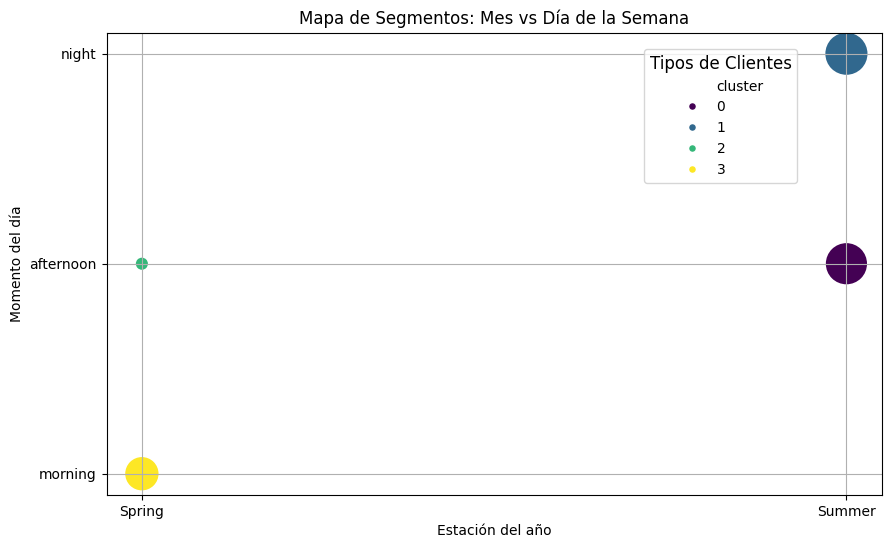

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_customer_profile, x='season_mode', y='day_moment_mode', 
                size='customers_count', hue="cluster", palette='viridis', 
                sizes=(100, 1000), legend="full")

plt.title('Mapa de Segmentos: Mes vs Día de la Semana')
plt.xlabel('Estación del año')
plt.ylabel('Momento del día')
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:5], labels[0:5], title='Tipos de Clientes', 
            title_fontsize='12', loc='upper right', bbox_to_anchor=(0.90, 0.98))

#### Observaciones: 
> - La grafica presenta una distribucion de clusters bien diferenciada, indica que el número de clusters en los que se ha agrupado a los clientes es el correcto.
> - El primero grupo, `cluster 0`, de color morado representa a los clientes que efectuan compras en la tarde durante la estacion de verano. Sus compras mas recurrentes son:computers_accessories, watches_gifts y health_beauty. El gasto promedio es de 1336.66 R$
> - El Grupo minoritario en azul `cluster 1`, representa los clientes que suelen hacer compras en verano durante la noche. Sus compras mas recurrentes son: health_beauty, bed_bath_table y sports_leisure. El gasto promedio es de 143.68 R$
> - `El cluster 2` en verde, representa los clientes que realizan compras en verano, durante la tarde . Sus compras mas recurrentes son: bed_bath_table, health_beauty y sports_leisure. El gasto promedio es de 141.56 R$
> - Por último el `cluster 3` en amarillo representa los clientes que realizan compras en primavera por la mañana. Sus compras mas recurrentes son: bed_bath_table, health_beauty y furniture_decor. El gasto promedio es de 143.97 R$

In [15]:
df.iloc[7]

product_category_name        auto
payment_value              175.26
day_moment                  night
day_type                  weekend
season                     Summer
hour                           21
hour_spline_0            0.380031
hour_spline_1            0.566724
hour_spline_2            0.046232
hour_spline_3            0.007014
cluster                         1
Name: 7, dtype: object

## Guardar datos

In [16]:
df.to_csv("../data/processed/olist_clustering.csv", index=False)
df_scaled.to_csv("../data/processed/olist_scaled_clustering.csv", index=False)